# Predicting LLM Activations with QA-Emb

This notebook extends the QA-Emb paper (Benara et al., 2024) to predict **LLM internal activations** instead of fMRI voxels. Uses the same fMRI story corpus (OpenNeuro ds003020) for direct comparison with brain results.

**Pipeline:**
1. Prepare text n-grams from the full fMRI story corpus (same stories used in the paper)
2. Extract Llama 3-8B hidden states at layers 0 (first), 16 (middle), 31 (last)
3. Compute QA-Emb: answer 674 yes/no questions per n-gram
4. PCA on activations → top 100 components (matching fMRI paper)
5. Ridge regression: QA-Emb → PCA components (story-based train/test split)
6. Evaluate: can interpretable yes/no questions predict LLM representations?

## 1. Setup & Installs

In [1]:
!pip install -q transformers accelerate datasets scikit-learn matplotlib numpy torch

In [2]:
import json
import os
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
from datasets import load_dataset
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name()}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Matplotlib is building the font cache; this may take a moment.


Using device: cuda
GPU: NVIDIA H200
Memory: 150.1 GB


## 2. Configure SCF Paths

`QA_CACHE_ROOT` points at the paper authors' precomputed QA-Emb cache (read-only). `CACHE_DIR` is where this notebook writes activation checkpoints. Both live under `/scratch/users/arihant_kaul/` because the `accounts` filesystem has only a 10 GB user quota and the activation cache alone will be ~9 GB.

In [3]:
QA_CACHE_ROOT = '/scratch/users/arihant_kaul/fmri_cached_qa_features'
CACHE_DIR = '/scratch/users/arihant_kaul/qa_emb_activations'
os.makedirs(CACHE_DIR, exist_ok=True)

assert os.path.isdir(QA_CACHE_ROOT), f'QA cache missing: {QA_CACHE_ROOT}'
print(f'QA cache:    {QA_CACHE_ROOT}')
print(f'Write cache: {CACHE_DIR}')

QA cache:    /scratch/users/arihant_kaul/fmri_cached_qa_features
Write cache: /scratch/users/arihant_kaul/qa_emb_activations


## 3. Load the 674 Questions

Read the question list from the train metadata pickle's `columns` field. This is the source of truth: it guarantees `QUESTIONS[i]` is the question that produced QA-Emb column `i`, with no risk of column-order drift.

In [4]:
import pickle

LLAMA_FOLDER = f'{QA_CACHE_ROOT}/meta-llama___Meta-Llama-3-8B-Instruct'

with open(f'{LLAMA_FOLDER}/v3_boostexamples_train_metadata.pkl', 'rb') as f:
    meta_train = pickle.load(f)
QUESTIONS = list(meta_train['columns'])
assert len(QUESTIONS) == 674

print(f'Loaded {len(QUESTIONS)} questions')
print(f'Examples: {QUESTIONS[:3]}')

Loaded 674 questions
Examples: ['Does the input contain a measurement?', 'Does the input contain a number?', 'Does the input contain a question?']


In [5]:
with open(f'{LLAMA_FOLDER}/v3_boostexamples_test_metadata.pkl', 'rb') as f:
    meta_test = pickle.load(f)

train_ngrams = list(meta_train['index'])
test_ngrams  = list(meta_test['index'])
ngrams = train_ngrams + test_ngrams

assert len(train_ngrams) == 184564, len(train_ngrams)
assert len(test_ngrams)  == 5951,   len(test_ngrams)

print(f'Train: {len(train_ngrams)}, Test: {len(test_ngrams)}, Total: {len(ngrams)}')
print('Example train n-grams:')
for s in train_ngrams[:3]:
    print(f'  "{s}"')

Train: 184564, Test: 5951, Total: 190515
Example train n-grams:
  ""
  "for"
  "for the"


## 5. Load Llama 3-8B-Instruct

We load the model in native float16 (no quantization) for extracting exact hidden states.

In [6]:
from huggingface_hub import login

_token = os.environ.get('HF_TOKEN') or os.environ.get('HUGGING_FACE_HUB_TOKEN')
if _token:
    login(token=_token, add_to_git_credential=False)
else:
    login()  # interactive fallback (Colab/local)


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [7]:
MODEL_NAME = 'meta-llama/Meta-Llama-3-8B-Instruct'

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map='auto',
)
model.eval()

num_layers = model.config.num_hidden_layers
hidden_size = model.config.hidden_size
print(f'Model loaded: {num_layers} layers, hidden size {hidden_size}')
print(f'Layers to extract: 0 (first), {num_layers // 2} (middle), {num_layers - 1} (last)')

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Model loaded: 32 layers, hidden size 4096
Layers to extract: 0 (first), 16 (middle), 31 (last)


## 6. Extract Activations

For each n-gram, we extract the **last token's hidden state** at layers 0, 16, and 31. Batch size is 8 to avoid GPU OOM (storing all 33 layer hidden states is memory-intensive). Checkpoints to `CACHE_DIR` every 512 samples.

In [8]:
LAYER_INDICES = [0, num_layers // 2, num_layers - 1]  # [0, 16, 31]
BATCH_SIZE_ACT = 8  # reduced from 32 to avoid OOM with output_hidden_states
CHECKPOINT_EVERY = 512

cache_file = os.path.join(CACHE_DIR, 'activations_full.npz')
partial_file = os.path.join(CACHE_DIR, 'activations_full_partial.npz')

if os.path.exists(cache_file):
    print('Loading cached activations...')
    cached = np.load(cache_file)
    activations = {int(k.split('_')[1]): cached[k] for k in cached.files}
else:
    n_total = len(ngrams)
    torch.cuda.empty_cache()

    # Check for partial progress
    if os.path.exists(partial_file):
        cached = np.load(partial_file)
        start = int(cached['progress'])
        acts = {int(k.split('_')[1]): cached[k] for k in cached.files if k != 'progress'}
        for l in LAYER_INDICES:
            full = np.zeros((n_total, hidden_size), dtype=np.float32)
            full[:start] = acts[l]
            acts[l] = full
        print(f'Resuming activation extraction from sample {start}/{n_total}')
    else:
        start = 0
        acts = {l: np.zeros((n_total, hidden_size), dtype=np.float32) for l in LAYER_INDICES}

    for i in tqdm(range(start, n_total, BATCH_SIZE_ACT), desc='Extracting activations'):
        batch = ngrams[i:i + BATCH_SIZE_ACT]
        inputs = tokenizer(
            batch, return_tensors='pt', padding=True,
            truncation=True, max_length=128,
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)

        hidden_states = outputs.hidden_states
        seq_lengths = inputs['attention_mask'].sum(dim=1) - 1

        for l in LAYER_INDICES:
            h = hidden_states[l + 1][torch.arange(len(batch)), seq_lengths]
            acts[l][i:i + len(batch)] = h.cpu().float().numpy()

        # Free GPU memory
        del outputs, hidden_states, inputs
        torch.cuda.empty_cache()

        # Periodic checkpoint
        done = i + len(batch)
        if done % CHECKPOINT_EVERY < BATCH_SIZE_ACT or done == n_total:
            save_dict = {f'layer_{l}': acts[l][:done] for l in LAYER_INDICES}
            save_dict['progress'] = np.array(done)
            np.savez(partial_file, **save_dict)

    activations = acts
    np.savez(cache_file, **{f'layer_{l}': v for l, v in activations.items()})
    if os.path.exists(partial_file):
        os.remove(partial_file)
    print('Activations saved to final cache.')

for l in LAYER_INDICES:
    print(f'Layer {l}: shape {activations[l].shape}')

Loading cached activations...


Layer 0: shape (190515, 4096)
Layer 16: shape (190515, 4096)
Layer 31: shape (190515, 4096)


## 7. Load Precomputed QA-Emb (Llama-3-8B)

Single-model setup: load the Llama-3-8B-Instruct answers from the precomputed cache, concatenate train + test, and cast bool → float32. No ensemble, no API calls.

In [9]:
qa_train = np.load(f'{LLAMA_FOLDER}/v3_boostexamples_answers_train_numpy.npz')['arr_0']
qa_test  = np.load(f'{LLAMA_FOLDER}/v3_boostexamples_answers_test_numpy.npz')['arr_0']

assert qa_train.shape == (184564, 674), qa_train.shape
assert qa_test.shape  == (5951, 674),   qa_test.shape

qa_emb = np.concatenate([qa_train, qa_test], axis=0).astype(np.float32)
del qa_train, qa_test

N_QUESTIONS = qa_emb.shape[1]
print(f'QA-Emb shape: {qa_emb.shape}')
print(f'Mean yes-rate: {qa_emb.mean():.3f}')
print(f'Per-question yes-rate range: [{qa_emb.mean(axis=0).min():.3f}, {qa_emb.mean(axis=0).max():.3f}]')

QA-Emb shape: (190515, 674)
Mean yes-rate: 0.305
Per-question yes-rate range: [0.001, 0.993]


## 8. PCA on Activations

For each layer, we run PCA on the activation matrix and extract the top 100 components (matching the fMRI paper, now justified with ~27k samples). PCA is fit on training data only to avoid leakage.

Train: 184564, Test: 5951 (story-based split)


Layer 0: PCA shape (190515, 100), variance explained (100 PCs) = 0.470


Layer 16: PCA shape (190515, 100), variance explained (100 PCs) = 0.691


Layer 31: PCA shape (190515, 100), variance explained (100 PCs) = 0.600


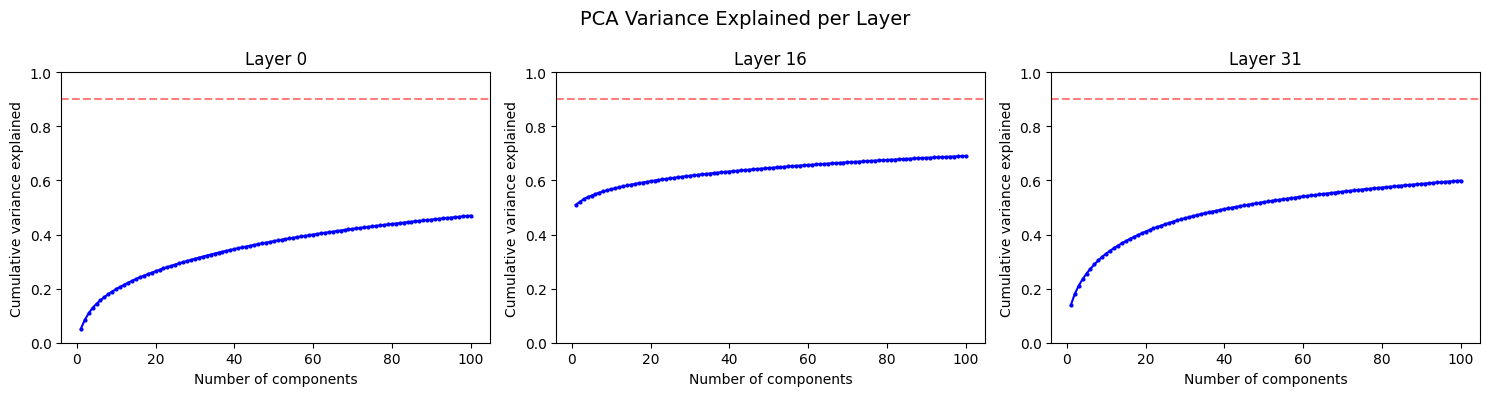

In [10]:
N_PCA_COMPONENTS = 100

# Story-based train/test split (matching the fMRI paper)
n_train = len(train_ngrams)
n_test = len(test_ngrams)
train_idx = np.arange(n_train)
test_idx = np.arange(n_train, n_train + n_test)
print(f'Train: {n_train}, Test: {n_test} (story-based split)')

pca_models = {}
pca_activations = {}

fig, axes = plt.subplots(1, len(LAYER_INDICES), figsize=(15, 4))

for ax_idx, layer_idx in enumerate(LAYER_INDICES):
    # Fit PCA on training data only
    pca = PCA(n_components=N_PCA_COMPONENTS)
    pca.fit(activations[layer_idx][train_idx])

    # Transform both train and test
    pca_act = pca.transform(activations[layer_idx])

    pca_models[layer_idx] = pca
    pca_activations[layer_idx] = pca_act

    cumvar = np.cumsum(pca.explained_variance_ratio_)
    axes[ax_idx].plot(range(1, N_PCA_COMPONENTS + 1), cumvar, 'b-o', markersize=2)
    axes[ax_idx].set_xlabel('Number of components')
    axes[ax_idx].set_ylabel('Cumulative variance explained')
    axes[ax_idx].set_title(f'Layer {layer_idx}')
    axes[ax_idx].axhline(y=0.9, color='r', linestyle='--', alpha=0.5)
    axes[ax_idx].set_ylim(0, 1)

    print(f'Layer {layer_idx}: PCA shape {pca_act.shape}, '
          f'variance explained ({N_PCA_COMPONENTS} PCs) = {cumvar[-1]:.3f}')

plt.suptitle('PCA Variance Explained per Layer', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Ridge Regression: QA-Emb → PCA Components

For each layer, we fit a ridge regression from the 674-dim QA-Emb to the 100-dim PCA activation space. We use `RidgeCV` with built-in cross-validation for alpha selection. Train/test split is story-based (matching the fMRI paper).

In [11]:
ALPHAS = np.logspace(-1, 4, 20)  # Ridge regularization candidates

X_train = qa_emb[train_idx]
X_test = qa_emb[test_idx]

ridge_cache = os.path.join(CACHE_DIR, 'ridge_results.npz')

if os.path.exists(ridge_cache):
    print(f'Loading cached Ridge results from {ridge_cache}')
    cached = np.load(ridge_cache, allow_pickle=True)
    results = cached['results'].item()
    for layer_idx in LAYER_INDICES:
        r = results[layer_idx]
        print(f'Layer {layer_idx}: mean r = {r["mean_corr"]:.4f}, '
              f'best alpha = {r["best_alpha"]:.2f}, '
              f'top-5 corrs = {np.sort(r["correlations"])[::-1][:5].round(3)}')
else:
    results = {}
    for layer_idx in LAYER_INDICES:
        Y_train = pca_activations[layer_idx][train_idx]
        Y_test = pca_activations[layer_idx][test_idx]

        ridge = RidgeCV(alphas=ALPHAS, scoring='neg_mean_squared_error')
        ridge.fit(X_train, Y_train)

        Y_pred = ridge.predict(X_test)

        correlations = []
        for comp in range(N_PCA_COMPONENTS):
            if np.std(Y_test[:, comp]) > 1e-10 and np.std(Y_pred[:, comp]) > 1e-10:
                r, _ = pearsonr(Y_test[:, comp], Y_pred[:, comp])
                correlations.append(r)
            else:
                correlations.append(0.0)
        correlations = np.array(correlations)

        results[layer_idx] = {
            'coef': ridge.coef_,
            'correlations': correlations,
            'mean_corr': float(np.mean(correlations)),
            'best_alpha': float(ridge.alpha_),
            'Y_pred': Y_pred,
            'Y_test': Y_test,
        }

        print(f'Layer {layer_idx}: mean r = {np.mean(correlations):.4f}, '
              f'best alpha = {ridge.alpha_:.2f}, '
              f'top-5 corrs = {np.sort(correlations)[::-1][:5].round(3)}')

    np.savez(ridge_cache, results=results)
    print(f'Saved Ridge results to {ridge_cache}')


Loading cached Ridge results from /scratch/users/arihant_kaul/qa_emb_activations/ridge_results.npz
Layer 0: mean r = 0.1797, best alpha = 263.67, top-5 corrs = [0.484 0.41  0.39  0.297 0.278]
Layer 16: mean r = 0.3704, best alpha = 23.36, top-5 corrs = [0.694 0.646 0.628 0.577 0.562]
Layer 31: mean r = 0.4059, best alpha = 483.29, top-5 corrs = [0.683 0.65  0.599 0.579 0.555]


## 10. Evaluation & Visualization

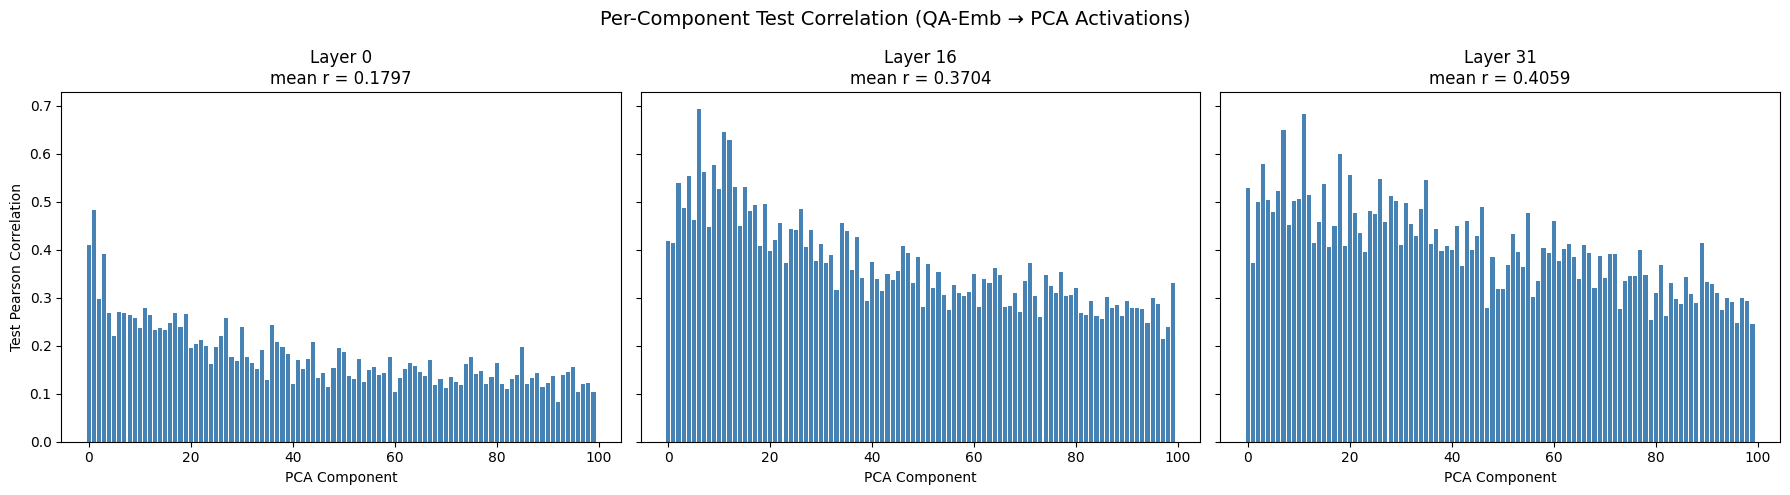

In [12]:
# --- A: Per-component correlation for each layer ---
fig, axes = plt.subplots(1, len(LAYER_INDICES), figsize=(18, 5), sharey=True)

for ax_idx, layer_idx in enumerate(LAYER_INDICES):
    corrs = results[layer_idx]['correlations']
    colors = ['steelblue' if c > 0 else 'salmon' for c in corrs]
    axes[ax_idx].bar(range(N_PCA_COMPONENTS), corrs, color=colors, width=0.8)
    axes[ax_idx].axhline(y=0, color='black', linewidth=0.5)
    axes[ax_idx].set_xlabel('PCA Component')
    axes[ax_idx].set_title(
        f'Layer {layer_idx}\nmean r = {results[layer_idx]["mean_corr"]:.4f}'
    )
    if ax_idx == 0:
        axes[ax_idx].set_ylabel('Test Pearson Correlation')

plt.suptitle('Per-Component Test Correlation (QA-Emb → PCA Activations)', fontsize=14)
plt.tight_layout()
plt.show()

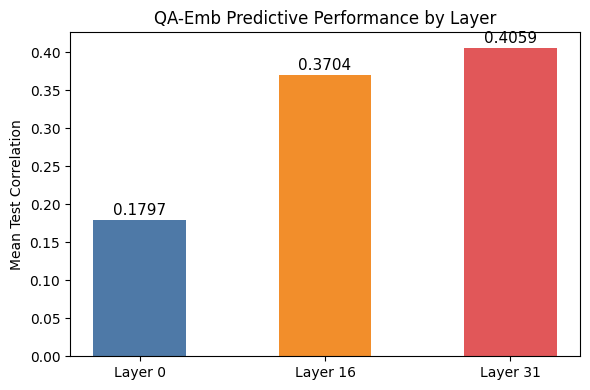

In [13]:
# --- B: Layer comparison summary ---
layer_names = [f'Layer {l}' for l in LAYER_INDICES]
mean_corrs = [results[l]['mean_corr'] for l in LAYER_INDICES]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(layer_names, mean_corrs, color=['#4e79a7', '#f28e2b', '#e15759'], width=0.5)
ax.set_ylabel('Mean Test Correlation')
ax.set_title('QA-Emb Predictive Performance by Layer')

for bar, val in zip(bars, mean_corrs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

In [14]:
# --- C: Top questions by regression weight magnitude ---
for layer_idx in LAYER_INDICES:
    coef = results[layer_idx]['coef']  # shape: (N_PCA_COMPONENTS, 674)
    # Aggregate importance: mean absolute weight across all PCA components
    question_importance = np.mean(np.abs(coef), axis=0)
    top_q_indices = np.argsort(question_importance)[::-1][:10]

    print(f'\n=== Layer {layer_idx}: Top 10 most predictive questions ===')
    for rank, q_idx in enumerate(top_q_indices):
        print(f'  {rank+1}. [{question_importance[q_idx]:.4f}] {QUESTIONS[q_idx]}')



=== Layer 0: Top 10 most predictive questions ===
  1. [0.0043] Does the sentence use a common cliché?
  2. [0.0028] Is the sentence a question?
  3. [0.0024] Does the sentence include a number or statistic?
  4. [0.0023] Is the sentence repetitive or redundant?
  5. [0.0020] Does the sentence include a comparison or simile?
  6. [0.0020] Does the sentence contain a negation?
  7. [0.0020] Does the sentence include a rhetorical question?
  8. [0.0020] Is a specific scientific field or discipline mentioned?
  9. [0.0020] Does the sentence contain a question?
  10. [0.0020] Does the sentence involve mathematical reasoning?

=== Layer 16: Top 10 most predictive questions ===
  1. [0.1792] Does the sentence use a common cliché?
  2. [0.1064] Is the sentence a question?
  3. [0.0616] Is the sentence repetitive or redundant?
  4. [0.0551] Is a specific scientific field or discipline mentioned?
  5. [0.0522] Does the story involve a pet or domestic animal?
  6. [0.0486] Is a natural phenomen

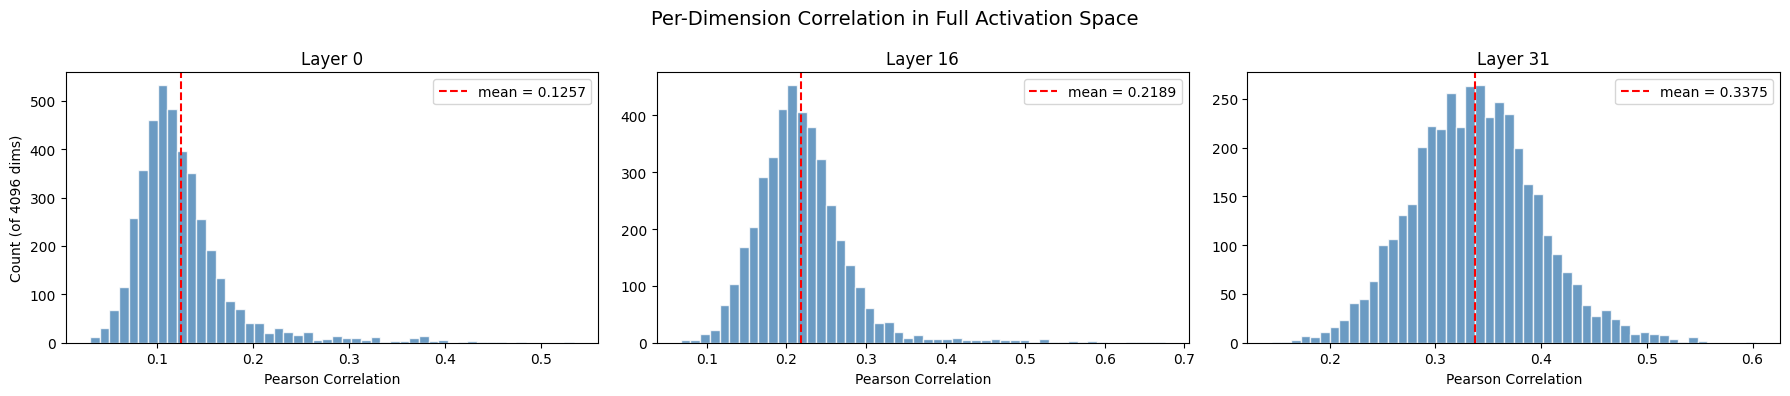

In [15]:
# --- D: Reconstruction in full activation space ---
# Project PCA predictions back to full 4096-dim space and measure per-dimension correlation

fig, axes = plt.subplots(1, len(LAYER_INDICES), figsize=(18, 4))

for ax_idx, layer_idx in enumerate(LAYER_INDICES):
    pca = pca_models[layer_idx]
    Y_pred_pca = results[layer_idx]['Y_pred']  # (test, 50)

    # Reconstruct in full space
    Y_pred_full = pca.inverse_transform(Y_pred_pca)  # (test, 4096)
    Y_test_full = activations[layer_idx][test_idx]     # (test, 4096)

    # Per-dimension correlation
    dim_corrs = []
    for d in range(hidden_size):
        if np.std(Y_test_full[:, d]) > 1e-10 and np.std(Y_pred_full[:, d]) > 1e-10:
            r, _ = pearsonr(Y_test_full[:, d], Y_pred_full[:, d])
            dim_corrs.append(r)
        else:
            dim_corrs.append(0.0)
    dim_corrs = np.array(dim_corrs)

    # Histogram of per-dimension correlations
    axes[ax_idx].hist(dim_corrs, bins=50, color='steelblue', alpha=0.8, edgecolor='white')
    axes[ax_idx].axvline(x=np.mean(dim_corrs), color='red', linestyle='--',
                          label=f'mean = {np.mean(dim_corrs):.4f}')
    axes[ax_idx].set_xlabel('Pearson Correlation')
    axes[ax_idx].set_title(f'Layer {layer_idx}')
    axes[ax_idx].legend()
    if ax_idx == 0:
        axes[ax_idx].set_ylabel('Count (of 4096 dims)')

plt.suptitle('Per-Dimension Correlation in Full Activation Space', fontsize=14)
plt.tight_layout()
plt.show()

## 11. Feature Selection: How Few Questions Suffice?

Mirroring the paper's finding that 29 questions beat the 985-dim Eng1000 baseline, we test how QA-Emb performance degrades as we use fewer questions (selected by Elastic Net).

In [16]:
from sklearn.linear_model import MultiTaskElasticNet

# Paper spec (Benara et al. 2024, §3): MultiTaskElasticNet (no CV) over 20
# log-spaced alphas in [1e-3, 1], default l1_ratio=0.5. Each alpha gives a
# different number of selected questions; for each, we refit Ridge on the
# selected subset and measure test correlation.

def analyze_layer(ANALYSIS_LAYER):
    cache_path = os.path.join(CACHE_DIR, f'analyze_layer_{ANALYSIS_LAYER}.npz')
    partial_path = os.path.join(CACHE_DIR, f'analyze_layer_{ANALYSIS_LAYER}_partial.npz')

    if os.path.exists(cache_path):
        print(f'Loading cached analyze_layer({ANALYSIS_LAYER}) from {cache_path}')
        cache = np.load(cache_path)
        alphas_path = cache['alphas']
        n_nonzero_arr = cache['n_nonzero']
        perf_arr = cache['perf']
    else:
        Y_train_a = pca_activations[ANALYSIS_LAYER][train_idx]
        Y_test_a = pca_activations[ANALYSIS_LAYER][test_idx]

        # Walk path from strong → weak regularization to leverage warm starts
        alphas_path = np.logspace(0, -3, 20)
        n_alphas = len(alphas_path)

        # Resume from partial checkpoint if present
        if os.path.exists(partial_path):
            p = np.load(partial_path, allow_pickle=True)
            done_n = int(p['done'])
            n_nonzero_list = list(p['n_nonzero'][:done_n])
            perf_list = list(p['perf'][:done_n])
            saved_coef = p['enet_coef'] if 'enet_coef' in p.files else None
            saved_intercept = p['enet_intercept'] if 'enet_intercept' in p.files else None
            print(f'Resuming layer {ANALYSIS_LAYER} from alpha index {done_n}/{n_alphas}')
        else:
            done_n = 0
            n_nonzero_list = []
            perf_list = []
            saved_coef = None
            saved_intercept = None

        enet = MultiTaskElasticNet(
            l1_ratio=0.5, max_iter=2000, tol=1e-3, warm_start=True,
        )
        # Seed warm-start state if resuming
        if saved_coef is not None:
            enet.coef_ = saved_coef
            enet.intercept_ = saved_intercept
            enet.n_iter_ = 0
            enet.n_features_in_ = saved_coef.shape[1]
            enet.dual_gap_ = 0.0

        for i in tqdm(range(done_n, n_alphas), desc=f'Layer {ANALYSIS_LAYER} ENet path'):
            alpha = alphas_path[i]
            enet.alpha = float(alpha)
            enet.fit(X_train, Y_train_a)

            # Multi-task L21 penalty zeros entire rows; question is selected
            # iff its row in coef_ has any non-zero element.
            row_norms = np.linalg.norm(enet.coef_, axis=0)
            selected_mask = row_norms > 1e-10
            n_selected = int(selected_mask.sum())

            if n_selected == 0:
                n_nonzero_list.append(0)
                perf_list.append(0.0)
                print(f'  alpha={alpha:.4f}: 0 questions selected')
            else:
                X_tr_sub = X_train[:, selected_mask]
                X_te_sub = X_test[:, selected_mask]
                ridge_sub = RidgeCV(alphas=ALPHAS)
                ridge_sub.fit(X_tr_sub, Y_train_a)
                Y_pred_sub = ridge_sub.predict(X_te_sub)

                corrs_sub = []
                for comp in range(N_PCA_COMPONENTS):
                    if np.std(Y_test_a[:, comp]) > 1e-10 and np.std(Y_pred_sub[:, comp]) > 1e-10:
                        r, _ = pearsonr(Y_test_a[:, comp], Y_pred_sub[:, comp])
                        corrs_sub.append(r)
                    else:
                        corrs_sub.append(0.0)
                mean_corr = float(np.mean(corrs_sub))

                n_nonzero_list.append(n_selected)
                perf_list.append(mean_corr)
                print(f'  alpha={alpha:.4f}: {n_selected} questions, mean r = {mean_corr:.4f}')

            # Checkpoint after each alpha — pad to full length so the file
            # is always loadable. `done` tracks the real progress.
            done = i + 1
            np.savez(
                partial_path,
                done=np.array(done),
                alphas=alphas_path,
                n_nonzero=np.array(n_nonzero_list + [0] * (n_alphas - done)),
                perf=np.array(perf_list + [0.0] * (n_alphas - done)),
                enet_coef=enet.coef_,
                enet_intercept=enet.intercept_,
            )

        n_nonzero_arr = np.array(n_nonzero_list)
        perf_arr = np.array(perf_list)
        np.savez(cache_path,
                 alphas=alphas_path,
                 n_nonzero=n_nonzero_arr,
                 perf=perf_arr)
        if os.path.exists(partial_path):
            os.remove(partial_path)
        print(f'Saved analyze_layer({ANALYSIS_LAYER}) to {cache_path}')

    # Plot: performance vs number of selected questions
    order = np.argsort(n_nonzero_arr)
    nq_sorted = n_nonzero_arr[order]
    perf_sorted = perf_arr[order]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(nq_sorted, perf_sorted, 'b-o', markersize=6)
    ax.set_xlabel('Number of Questions Selected by Elastic Net')
    ax.set_ylabel('Mean Test Correlation')
    ax.set_title(f'QA-Emb Performance vs. # Selected Questions (Layer {ANALYSIS_LAYER})')
    if nq_sorted.max() > 1:
        ax.set_xscale('symlog', linthresh=1)
    plt.tight_layout()
    plt.show()

    print('\nPerformance by number of selected questions:')
    for nq, perf in zip(nq_sorted, perf_sorted):
        print(f'  {nq:4d} questions: mean r = {perf:.4f}')


Loading cached analyze_layer(0) from /scratch/users/arihant_kaul/qa_emb_activations/analyze_layer_0.npz


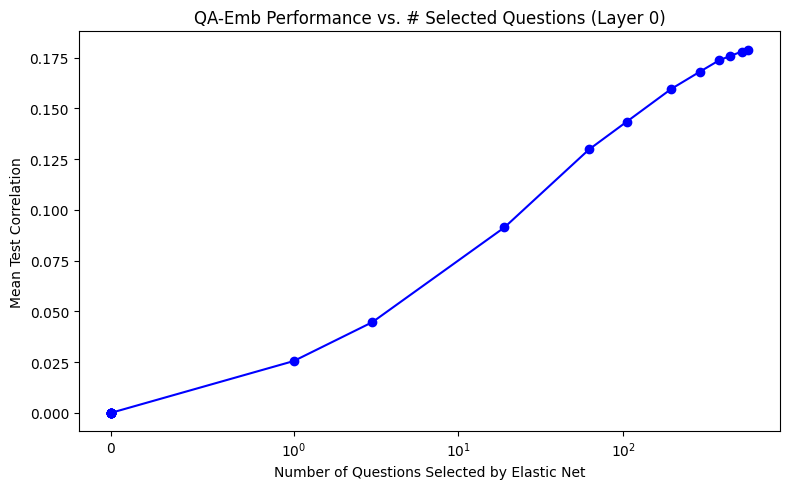


Performance by number of selected questions:
     0 questions: mean r = 0.0000
     0 questions: mean r = 0.0000
     0 questions: mean r = 0.0000
     0 questions: mean r = 0.0000
     0 questions: mean r = 0.0000
     0 questions: mean r = 0.0000
     0 questions: mean r = 0.0000
     0 questions: mean r = 0.0000
     0 questions: mean r = 0.0000
     1 questions: mean r = 0.0256
     3 questions: mean r = 0.0447
    19 questions: mean r = 0.0913
    62 questions: mean r = 0.1297
   105 questions: mean r = 0.1434
   196 questions: mean r = 0.1596
   291 questions: mean r = 0.1680
   381 questions: mean r = 0.1736
   445 questions: mean r = 0.1758
   523 questions: mean r = 0.1779
   573 questions: mean r = 0.1790


In [17]:
analyze_layer(0)

Layer 16 ENet path:   0%|          | 0/20 [00:00<?, ?it/s]

  alpha=1.0000: 0 questions selected


  alpha=0.6952: 0 questions selected


  alpha=0.4833: 8 questions, mean r = 0.1067


  alpha=0.3360: 106 questions, mean r = 0.2704


...

  alpha=0.0043: 669 questions, mean r = 0.3710


  alpha=0.0030: 672 questions, mean r = 0.3710


  alpha=0.0021: 674 questions, mean r = 0.3710


  alpha=0.0014: 674 questions, mean r = 0.3710


  alpha=0.0010: 674 questions, mean r = 0.3710
Saved analyze_layer(16) to /scratch/users/arihant_kaul/qa_emb_activations/analyze_layer_16.npz


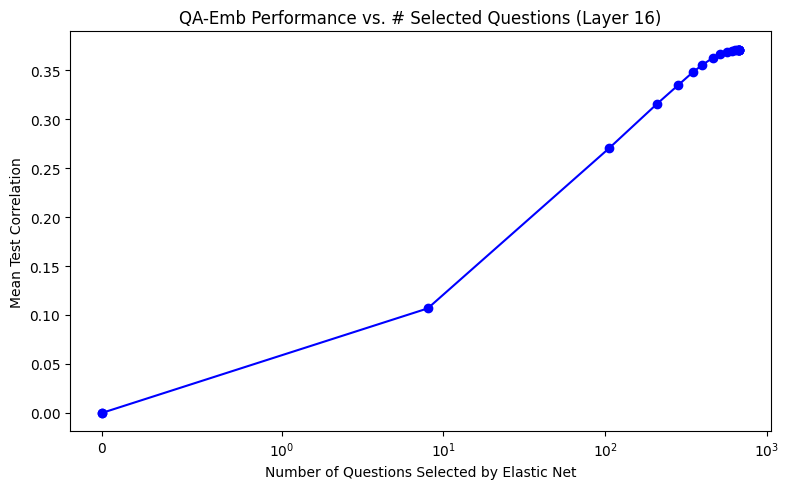


Performance by number of selected questions:
     0 questions: mean r = 0.0000
     0 questions: mean r = 0.0000
     8 questions: mean r = 0.1067
   106 questions: mean r = 0.2704
   208 questions: mean r = 0.3152
   283 questions: mean r = 0.3347
   347 questions: mean r = 0.3476
   397 questions: mean r = 0.3551
   466 questions: mean r = 0.3628
   516 questions: mean r = 0.3659
   570 questions: mean r = 0.3687
   604 questions: mean r = 0.3698
   636 questions: mean r = 0.3706
   655 questions: mean r = 0.3709
   664 questions: mean r = 0.3709
   669 questions: mean r = 0.3710
   672 questions: mean r = 0.3710
   674 questions: mean r = 0.3710
   674 questions: mean r = 0.3710
   674 questions: mean r = 0.3710


In [18]:
analyze_layer(num_layers//2)

Layer 31 ENet path:   0%|          | 0/20 [00:00<?, ?it/s]

  alpha=1.0000: 551 questions, mean r = 0.3986


  alpha=0.6952: 585 questions, mean r = 0.4015


  alpha=0.4833: 616 questions, mean r = 0.4038


  alpha=0.3360: 644 questions, mean r = 0.4054


...

  alpha=0.0043: 674 questions, mean r = 0.4066


  alpha=0.0030: 674 questions, mean r = 0.4066


  alpha=0.0021: 674 questions, mean r = 0.4066


  alpha=0.0014: 674 questions, mean r = 0.4066


  alpha=0.0010: 674 questions, mean r = 0.4066
Saved analyze_layer(31) to /scratch/users/arihant_kaul/qa_emb_activations/analyze_layer_31.npz


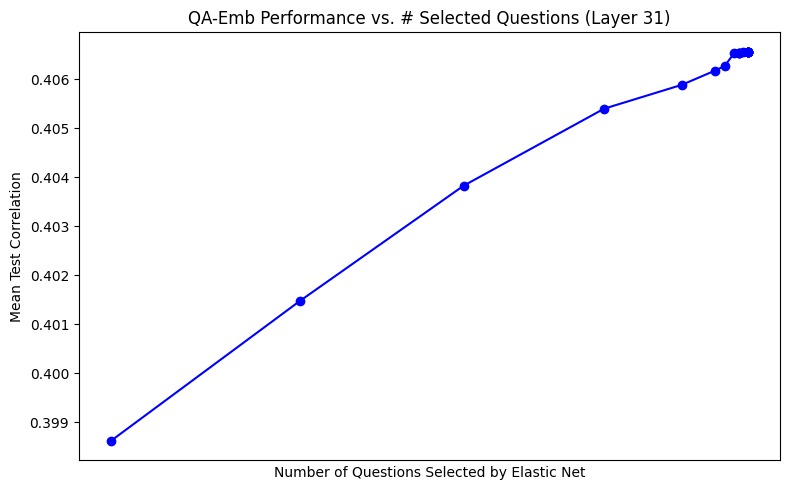


Performance by number of selected questions:
   551 questions: mean r = 0.3986
   585 questions: mean r = 0.4015
   616 questions: mean r = 0.4038
   644 questions: mean r = 0.4054
   660 questions: mean r = 0.4059
   667 questions: mean r = 0.4062
   669 questions: mean r = 0.4063
   671 questions: mean r = 0.4065
   672 questions: mean r = 0.4065
   672 questions: mean r = 0.4065
   672 questions: mean r = 0.4065
   673 questions: mean r = 0.4066
   674 questions: mean r = 0.4066
   674 questions: mean r = 0.4066
   674 questions: mean r = 0.4066
   674 questions: mean r = 0.4066
   674 questions: mean r = 0.4066
   674 questions: mean r = 0.4066
   674 questions: mean r = 0.4066
   674 questions: mean r = 0.4066


In [19]:
analyze_layer(num_layers-1)

## 12. Summary

This notebook tests whether interpretable yes/no question embeddings (QA-Emb) can predict the internal activations of Llama 3-8B, using the **full fMRI story corpus** from the paper for direct comparison with brain results.

**Setup:**
- Same narrative podcast transcripts (OpenNeuro ds003020) as the fMRI paper
- Story-based train/test split (matching the paper's methodology)
- 100 PCA components (matching the paper)
- 674 candidate questions

**Key results to examine:**
- Which layer is most predictable from interpretable questions?
- Do the same questions predict both brain activity AND LLM activations?
- How few questions suffice? (compare with the paper's 29-question result for fMRI)
- Can QA-Emb performance be compared directly with the fMRI paper's Pearson correlations?

**Next steps:**
- Compare QA-Emb predictive power against black-box baselines (e.g., BERT embeddings -> LLaMA activations)
- Generate new questions specifically optimized for predicting LLM activations
- Joint analysis: which questions predict both brain and LLM activations?